This script serves as a sanity check on the representation level.
The different data representations are used to classify call types as a proof of sufficient information.

DFA (PAFs), simple MLPs (LFCCs) and CNNs (spectrograms) are used to classify the different call types.

In [2]:
import pandas as pd
import numpy as np
import json
import random
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from sklearn.model_selection import StratifiedGroupKFold, permutation_test_score
from sklearn.utils import resample
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelBinarizer

In [3]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.RandomState(RANDOM_SEED)

RandomState(MT19937) at 0x13CE9BA40

### Create internal functions

In [5]:
def plot_confusion_matrix(true_labels, predicted_labels, class_names):  
    titles_options = [
        ("Confusion matrix, without normalization", None),
        ("Normalized confusion matrix", "true"),
    ]
    for title, normalize in titles_options:
        cm = confusion_matrix(true_labels, predicted_labels, normalize=normalize)
        plt.figure(figsize=(8, 6))
        if normalize:
            sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
        else:
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
        plt.title(title)
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')

    plt.show()  

In [6]:
# def _compute_roc_curve(val_targets, val_probs, num_classes):
#     val_targets = np.array(val_targets)
#     val_probs = np.array(val_probs)

#     all_labels_binarized = label_binarize(val_targets, classes=np.arange(num_classes))
#     fpr = {}
#     tpr = {}
#     roc_auc = {}

#     # For each class, compute the ROC curve and AUC
#     for i in range(num_classes):
#         fpr[i], tpr[i], _ = roc_curve(all_labels_binarized[:, i], val_probs[:, i])
#         roc_auc[i] = auc(fpr[i], tpr[i])

#     # Micro-average ROC curve
#     fpr["micro"], tpr["micro"], _ = roc_curve(all_labels_binarized.ravel(), val_probs.ravel())
#     roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

#     # Macro-average ROC curve
#     all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
#     mean_tpr = np.zeros_like(all_fpr)
#     for i in range(num_classes):
#         mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
#     mean_tpr /= num_classes

#     fpr["macro"] = all_fpr
#     tpr["macro"] = mean_tpr
#     roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

#     print(fpr["micro"].shape, tpr["micro"].shape, fpr["macro"].shape, tpr["macro"].shape, roc_auc["micro"], roc_auc["macro"])

#     return fpr, tpr, roc_auc

In [7]:
# def plot_roc_curve(true_labels, all_probs, num_classes, class_names):
#     fpr, tpr, roc_auc = _compute_roc_curve(true_labels, all_probs, num_classes)

#     # Plot ROC curve for each class
#     plt.figure(figsize=(10, 8))
#     for i in range(num_classes):
#         plt.plot(fpr[i], tpr[i], label = f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

#     # Plot micro-average and macro-average ROC curves
#     plt.plot(fpr["micro"], tpr["micro"], label=f"Micro-average (AUC = {roc_auc['micro']:.2f})", linestyle='--', color="blue")
#     plt.plot(fpr["macro"], tpr["macro"], label=f"Macro-average (AUC = {roc_auc['macro']:.2f})", linestyle='-.', color="navy")
    
#     # Plot the diagonal (random guess)
#     plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
    
#     # Configure the plot
#     plt.title("ROC Curve")
#     plt.xlabel("False Positive Rate")
#     plt.ylabel("True Positive Rate")
#     plt.legend(loc="lower right")
#     plt.grid()
#     plt.show()

In [8]:
def train_model(model, n_epochs, train_dl, device, optimizer, loss_criterion):
    # Train model
    model.train()
    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_dl:
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = loss_criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {running_loss / len(train_dl):.4f}")

In [9]:
# def plot_roc_curve_with_ci(all_fpr_micro, all_tpr_micro, all_fpr_macro, all_tpr_macro, alpha=0.95):
#     print(len(all_fpr_micro[0], all_fpr_micro[1]))
#     all_fpr_micro = np.asarray(all_fpr_micro)
#     all_tpr_micro = np.asarray(all_tpr_micro)
#     all_fpr_macro = np.asarray(all_fpr_macro)
#     all_tpr_macro = np.asarray(all_tpr_macro)

#     # Calculate mean and confidence intervals for micro-average
#     mean_fpr_micro = np.mean(all_fpr_micro, axis=0)
#     mean_tpr_micro = np.mean(all_tpr_micro, axis=0)
#     tpr_micro_lower = np.percentile(all_tpr_micro, (1 - alpha) / 2 * 100, axis=0)
#     tpr_micro_upper = np.percentile(all_tpr_micro, (1 + alpha) / 2 * 100, axis=0)

#     # Calculate mean and confidence intervals for macro-average
#     mean_fpr_macro = np.mean(all_fpr_macro, axis=0)
#     mean_tpr_macro = np.mean(all_tpr_macro, axis=0)
#     tpr_macro_lower = np.percentile(all_tpr_macro, (1 - alpha) / 2 * 100, axis=0)
#     tpr_macro_upper = np.percentile(all_tpr_macro, (1 + alpha) / 2 * 100, axis=0)

#     # Plot ROC curve with confidence intervals
#     plt.figure(figsize=(10, 8))

#     # micro-average
#     plt.plot(mean_fpr_micro, mean_tpr_micro, label=f"Micro-average (AUC = {auc(mean_fpr_micro, mean_tpr_micro):.2f})", linestyle='--', color="blue")
#     plt.fill_between(mean_fpr_micro, tpr_micro_lower, tpr_micro_upper, color='blue', alpha=0.2)

#     # macro-average
#     plt.plot(mean_fpr_macro, mean_tpr_macro, label=f"Macro-average (AUC = {auc(mean_fpr_macro, mean_tpr_macro):.2f})", linestyle='-.', color="navy")
#     plt.fill_between(mean_fpr_macro, tpr_macro_lower, tpr_macro_upper, color='navy', alpha=0.2)

#     plt.plot([0, 1], [0, 1], color="gray", linestyle="--")

#     plt.title("ROC Curve")
#     plt.xlabel("False Positive Rate")
#     plt.ylabel("True Positive Rate")
#     plt.legend(loc="lower right")
#     plt.grid()
#     plt.show()

In [10]:
def test_model(model, test_dl, device):
    true_labels = []
    predicted_labels = []
    all_probs = []
    model.eval()
    with torch.no_grad():
        for inputs, labels in test_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)  # Convert logits to probabilities
            
            _, predicted = torch.max(outputs, 1)
            
            true_labels.append(labels.cpu().numpy())
            predicted_labels.append(predicted.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
    
    true_labels = np.concatenate(true_labels, axis=0)
    predicted_labels = np.concatenate(predicted_labels, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)
    
    return true_labels, predicted_labels, all_probs

In [11]:
def create_evaluation_plots(true_labels, predicted_labels, label_encoder, all_probs=None, num_classes=None):
    y_test_labels = label_encoder.inverse_transform(true_labels)
    y_pred_labels = label_encoder.inverse_transform(predicted_labels)
    print(classification_report(y_test_labels, y_pred_labels))
    plot_confusion_matrix(y_test_labels, y_pred_labels, label_encoder.classes_)
    if all_probs is None:
        return
    assert not num_classes is None
    #plot_roc_curve(true_labels, all_probs, num_classes, label_encoder.classes_)
    
def evaluate_model(model, test_dl, device, label_encoder, num_classes):
    true_labels, predicted_labels, all_probs = test_model(model, test_dl, device)
    create_evaluation_plots(true_labels, predicted_labels, label_encoder, all_probs, num_classes)

In [12]:
def verify_splits(dataset, sgkf):
    """
    Verifies that StratifiedGroupKFold splits are not holding any of the same track IDs across sets.

    Args:
        dataset (LFCCDataset): The dataset object.
        sgkf (StratifiedGroupKFold): The StratifiedGroupKFold object.
    """
    df = dataset.df
    groups = dataset.groups
    y = df["encoded_call_type"]

    for fold, (train_idx, val_idx) in enumerate(sgkf.split(df, y, groups=groups)):
        train_groups = set(groups.iloc[train_idx])
        val_groups = set(groups.iloc[val_idx])

        assert train_groups.isdisjoint(val_groups), f"Overlap found in groups for Fold {fold + 1}"
    return True

In [13]:
def _plot_roc_auc_curves_cv(mean_fpr, mean_micro_tpr, micro_tprs_lower, micro_auc_scores, micro_tprs_upper, mean_macro_tpr, macro_auc_scores, macro_tprs_lower, macro_tprs_upper, n_classes, tprs_per_class, label_encoder, roc_auc):
    fig, ax = plt.subplots(figsize=(9, 9))
    # Plot micro-average ROC curve with CI
    ax.plot(
        mean_fpr,
        mean_micro_tpr,
        label=f"Micro-average ROC curve ± 1 std. dev.(AUC = {np.mean(micro_auc_scores):.2f})",
        color="deeppink",
        linestyle="--",
        linewidth=1.5,
    )
    ax.fill_between(
        mean_fpr,
        micro_tprs_lower,
        micro_tprs_upper,
        color="pink",
        alpha=0.2,
    )

    # Plot macro-average ROC curve with CI
    ax.plot(
        mean_fpr,
        mean_macro_tpr,
        label=f"Macro-average ROC curve ± 1 std. dev.(AUC = {np.mean(macro_auc_scores):.2f})",#np.mean([auc(fpr[class_idx], tpr[class_idx]) for class_idx in range(n_classes)])
        color="navy",
        linestyle="--",
        linewidth=1.5,
    )
    ax.fill_between(
        mean_fpr,
        macro_tprs_lower,
        macro_tprs_upper,
        color="blue",
        alpha=0.2,
    )

    # Plot average curve per class
    for class_idx in range(n_classes):
        mean_tpr = np.mean(tprs_per_class[class_idx], axis=0)
        std_tpr = np.std(tprs_per_class[class_idx], axis=0)
        tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
        tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

        # Plot mean ROC curve with AUC
        ax.plot(mean_fpr, mean_tpr, label=f"Class {label_encoder.inverse_transform([class_idx])[0]} ± 1 std. dev. (AUC = {roc_auc[class_idx]:.2f})")
        ax.fill_between(mean_fpr, tprs_lower, tprs_upper, alpha=0.2)

    # Plot random
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--", alpha=0.5)

    _ = ax.set(
        xlabel="False Positive Rate",
        ylabel="True Positive Rate",
        title="ROC One-vs-Rest multiclass",
    )
    
    ax.legend(loc="lower right")
    plt.show()  

In [14]:
# https://scikit-learn.org/1.5/auto_examples/model_selection/plot_roc_crossval.html accessed January 14th, 19:04pm
# https://scikit-learn.org/1.5/auto_examples/model_selection/plot_roc.html accessed January 14th, 20:17pm
def cross_validate(dataset, model_class, device, label_encoder, batch_size, learning_rate, n_splits=5, n_epochs=10, n_classes=6, **model_kwargs):
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED) # enables splitting by tracks
    
    assert verify_splits(dataset, sgkf)

    fold_results = []

    tprs_per_class = {class_idx: [] for class_idx in range(n_classes)}
    mean_fpr = np.linspace(0, 1, 1000)
    micro_tprs = []
    macro_tprs = []
    micro_auc_scores = []
    macro_auc_scores = []
    fpr, tpr, roc_auc = dict(), dict(), dict()

    fold_results = {
            'accuracy': [],
            'precision': [],
            'recall': [],
            'f1': [],
            'micro_auc': [],
            'macro_auc': [],
        }

    for fold, (train_idx, val_idx) in enumerate(sgkf.split(dataset.df, dataset.df["encoded_call_type"], groups=dataset.groups)):
        torch.cuda.empty_cache()
        print(f"\n--- Fold {fold + 1} ---")
        model = model_class(num_classes=n_classes, **model_kwargs).to(device)
        
        # Create data loaders for current fold
        train_subset = Subset(dataset, train_idx)
        val_subset = Subset(dataset, val_idx)
        train_dl = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
        val_dl = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
        
        # Instantiate model, loss, optimizer
        loss_criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        
        train_model(model, n_epochs, train_dl, device, optimizer, loss_criterion)

        val_targets, val_predictions, val_probs = test_model(model, val_dl, device)
        label_binarizer = LabelBinarizer().fit([y for _, y in dataset])
        y_onehot_test = label_binarizer.transform(val_targets)
        val_probs = np.array(val_probs)

        # Compute validation accuracy
        fold_accuracy = accuracy_score(val_targets, val_predictions)
        print(f"\nValidation Accuracy for Fold {fold + 1}: {fold_accuracy:.4f}")
        #-------------End of training---------    

        tprs_for_macro = []

        # Per class ROC curve
        for class_idx in range(n_classes):
            fpr[class_idx], tpr[class_idx], _ = roc_curve(y_onehot_test[:, class_idx], val_probs[:, class_idx])
            roc_auc[class_idx] = auc(fpr[class_idx], tpr[class_idx])
        
            # Interpolate TPR values on the fixed FPR grid
            interp_tpr = np.interp(mean_fpr, fpr[class_idx], tpr[class_idx])
            interp_tpr[0] = 0.0  # Ensure TPR starts at 0
            tprs_per_class[class_idx].append(interp_tpr)
            tprs_for_macro.append(interp_tpr)

            
        # Compute micro-average ROC curve and ROC area
        # store the fpr, tpr, and roc_auc for all averaging strategies
        fpr["micro"], tpr["micro"], _ = roc_curve(y_onehot_test.ravel(), val_probs.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
        micro_auc_scores.append(roc_auc["micro"])

        # Interpolate TPR values on the fixed FPR grid
        interp_tpr = np.interp(mean_fpr, fpr["micro"], tpr["micro"])
        interp_tpr[0] = 0.0  # Ensure TPR starts at 0
        micro_tprs.append(interp_tpr)
        
        print(f"  Micro-averaged One-vs-Rest ROC AUC score: {roc_auc['micro']:.2f}")

        # Compute the macro-average TPR for this fold
        macro_tpr = np.mean(tprs_for_macro, axis=0)
        macro_tpr[-1] = 1.0  # Ensure TPR ends at 1
        macro_tprs.append(macro_tpr)
        macro_auc = auc(mean_fpr, macro_tpr)

        print(f"  Macro-averaged One-vs-Rest ROC AUC score: {macro_auc:.2f}")
        macro_auc_scores.append(macro_auc)

        #-----------Additional metrics-----------
        fold_precision = precision_score(val_targets, val_predictions, average='weighted', zero_division=0)
        fold_recall = recall_score(val_targets, val_predictions, average='weighted', zero_division=0)
        fold_f1 = f1_score(val_targets, val_predictions, average='weighted', zero_division=0)

        print(f"  Accuracy: {fold_accuracy:.4f}")
        print(f"  Precision (weighted): {fold_precision:.4f}")
        print(f"  Recall (weighted): {fold_recall:.4f}")
        print(f"  F1-score (weighted): {fold_f1:.4f}")

        fold_results['accuracy'].append(fold_accuracy)
        fold_results['precision'].append(fold_precision)
        fold_results['recall'].append(fold_recall)
        fold_results['f1'].append(fold_f1)
        fold_results['micro_auc'].append(roc_auc['micro'])
        fold_results['macro_auc'].append(macro_auc)

    #-------------End of fold--------------

    metrics_summary = {
        metric: {
            'mean': np.mean(values),
            'std': np.std(values)
        } for metric, values in fold_results.items()
    }

    print("\nCross-Validation Results:")
    for metric, stats in metrics_summary.items():
        print(f"  {metric.capitalize()} - Mean: {stats['mean']:.4f}, Std Dev: {stats['std']:.4f}")

    # Compute mean and std for micro-average TPRs
    mean_micro_tpr = np.mean(micro_tprs, axis=0)
    std_micro_tpr = np.std(micro_tprs, axis=0)
    micro_tprs_upper = np.minimum(mean_micro_tpr + std_micro_tpr, 1)
    micro_tprs_lower = np.maximum(mean_micro_tpr - std_micro_tpr, 0)

    # Compute mean and std for macro-average TPRs
    mean_macro_tpr = np.mean(macro_tprs, axis=0)
    std_macro_tpr = np.std(macro_tprs, axis=0)
    macro_tprs_upper = np.minimum(mean_macro_tpr + std_macro_tpr, 1)
    macro_tprs_lower = np.maximum(mean_macro_tpr - std_macro_tpr, 0)

    #--------------Plots----------------
    roc_auc_data = {
        'mean_fpr': mean_fpr,
        'mean_micro_tpr': mean_micro_tpr,
        'micro_tprs_lower': micro_tprs_lower,
        'micro_auc_scores': micro_auc_scores,
        'micro_tprs_upper': micro_tprs_upper,
        'mean_macro_tpr': mean_macro_tpr,
        'macro_auc_scores': macro_auc_scores,
        'macro_tprs_lower': macro_tprs_lower,
        'macro_tprs_upper': macro_tprs_upper,
        'n_classes': n_classes,
        'tprs_per_class': tprs_per_class,
        'label_encoder': label_encoder,
        'roc_auc': roc_auc
    }
    _plot_roc_auc_curves_cv(**roc_auc_data)

    return metrics_summary

In [15]:
def bootstrap_model(dataset, model_class, device, batch_size, learning_rate, num_bootstrap_samples=10, n_epochs=10, **model_kwargs):
    bootstrap_results = []

    for i in range(num_bootstrap_samples):
        print(f"\n--- Bootstrap Sample {i + 1} ---")
        
        # Generate bootstrap sample (with replacement)
        indices = resample(range(len(dataset)), replace=True, n_samples=len(dataset), random_state=i)
        oob_indices = list(set(range(len(dataset))) - set(indices))  # Out-of-Bag (OOB) indices

        train_subset = Subset(dataset, indices)
        oob_subset = Subset(dataset, oob_indices)
        train_dl = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
        oob_dl = DataLoader(oob_subset, batch_size=batch_size, shuffle=False)
        
        # Instantiate model, loss, and optimizer
        model = model_class(**model_kwargs).to(device)
        loss_criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        
        train_model(model, n_epochs, train_dl, device, optimizer, loss_criterion)
        oob_targets, oob_predictions, _ = test_model(model, oob_dl, device)

        # Compute OOB accuracy
        if oob_targets: 
            oob_accuracy = accuracy_score(oob_targets, oob_predictions)
            print(f"OOB Accuracy for Bootstrap Sample {i + 1}: {oob_accuracy:.4f}")
            bootstrap_results.append(oob_accuracy)
        else:
            print("No OOB samples for this bootstrap iteration.")
            bootstrap_results.append(None)

    # Final bootstrap results
    print("\nBootstrap Results:")
    for i, acc in enumerate(bootstrap_results):
        print(f"Bootstrap Sample {i + 1}: {acc if acc is not None else 'N/A'}")
    valid_accuracies = [acc for acc in bootstrap_results if acc is not None]
    if valid_accuracies:
        print(f"Average OOB Accuracy: {sum(valid_accuracies) / len(valid_accuracies):.4f}")
    else:
        print("No valid OOB accuracy to average.")


### Load data

In [4]:
calls_df = pd.read_pickle("features.pkl")

In [16]:
representations_df = pd.read_pickle("latent_representations_CVAE_adam_2025_08_29.pkl")
representations_df["latent_representation"] = representations_df["latent_representation"].apply(lambda x: np.asarray(x))
calls_df = pd.merge(calls_df, representations_df, on="Clip ID")
calls_df = calls_df.rename(columns={"Call Type_x": "Call Type"})
calls_df = calls_df.drop(columns=["Call Type_y"])

In [17]:
calls_df = calls_df.dropna(subset=['latent_representation'])
calls_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6651 entries, 0 to 6650
Data columns (total 52 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Track ID                 6651 non-null   object 
 1   Clip ID                  6651 non-null   object 
 2   Goose ID                 6651 non-null   object 
 3   Location                 6651 non-null   object 
 4   Day                      6651 non-null   float64
 5   Month                    6651 non-null   float64
 6   Year                     6651 non-null   float64
 7   Date                     1016 non-null   object 
 8   Time                     6646 non-null   object 
 9   Recorder                 627 non-null    object 
 10  Microphone               6650 non-null   object 
 11  Comment                  996 non-null    object 
 12  Context                  344 non-null    object 
 13  Recorder ID              6651 non-null   object 
 14  Begin Time (s)          

In [18]:
len(calls_df["Goose ID"].unique())

107

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_23557/3964892079.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  hist = sns.histplot(


[]

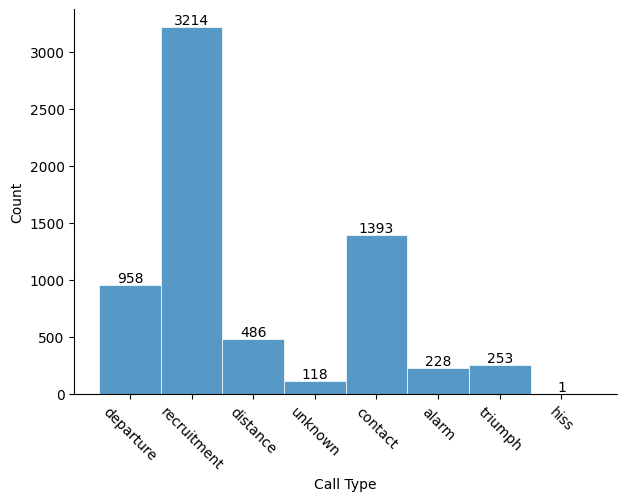

In [19]:
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)

hist = sns.histplot(
    calls_df,
    x="Call Type",
    multiple="stack",
    palette="viridis",
    edgecolor="1",
    linewidth=.5,
)

plt.xticks(rotation=-45)
ax.set_xlabel("Call Type")

# Add counts
for p in hist.patches:
    height = p.get_height()
    y = p.get_x() + p.get_width() / 2
    ax.annotate(f'{int(height)}', (y, height), ha='center', va='bottom')
    
plt.plot()

In [20]:
subsample_sizes = {
    'recruitment': 500,
    'contact': 500,
    'departure': 500,
    'hiss':0,
    'unknown': 0
}

# Randomly subsample classes to get roughly the same count for all sets
def subsample_group(group):
    call_type = group.name  # Group name corresponds to call type
    if call_type in subsample_sizes:
        return group.sample(n=subsample_sizes[call_type], random_state=42)
    return group  # Return untouched if no subsampling is needed

# Group by type and apply subsampling
calls_df = calls_df.groupby('Call Type', group_keys=False).apply(subsample_group)

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_23557/1861263288.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  calls_df = calls_df.groupby('Call Type', group_keys=False).apply(subsample_group)


## DFA

#### Audio features

In [21]:
feature_titles_list = [
    "duration",
    "spectrotemporal_entropy",
    "mean_dom",
    "min_dom",
    "max_dom",
    "range_dom",
    "mod_dom",
    "t_q1",
    "t_median",
    "t_q3",
    "temporal_centroid",
    "temporal_sd",
    "temporal_skew",
    "temporal_kurtosis",
    "fq_q1",
    "fq_median",
    "fq_q3",
    "spectral_flatness",
    "spectral_centroid",
    "spectral_sd",
    "spectral_skew",
    "spectral_kurtosis",
    "peak_frequency",
    "pse",
    "temporal_entropy"
    ]

# List of column names of PAFs
features_list = [
    "duration",
    "spectrotemporal_entropy",
    "mean_dom",
    "min_dom",
    "max_dom",
    "range_dom",
    "mod_dom",
    "t_q1",
    "t_median",
    "t_q3",
    "temporal_centroid",
    "temporal_sd",
    "temporal_skew",
    "temporal_kurtosis",
    "fq_q1",
    "fq_median",
    "fq_q3",
    "spectral_flatness",
    "spectral_centroid",
    "spectral_sd",
    "spectral_skew",
    "spectral_kurtosis",
    "peak_frequency",
    "pse",
    "temporal_entropy"
    ]

log_feature = [
    True, 
    True, 
    True, 
    True, 
    False, 
    False,  
    False,  
    False, 
    True, 
    True, 
    False,
    True, 
    True, 
    True, 
    True, 
    True, 
    True, 
    True, 
    True,
    True, 
    True, 
    True, 
    True, 
    True,
    False,
    False
]

In [22]:
len(features_list)

25

In [23]:
calls_df["pse"]

125     0.620489
126     0.534110
127     0.731650
128     0.676225
129     0.674611
          ...   
6494    0.644229
6495    0.528265
6496    0.533088
6497    0.550356
6498    0.570169
Name: pse, Length: 2467, dtype: float64

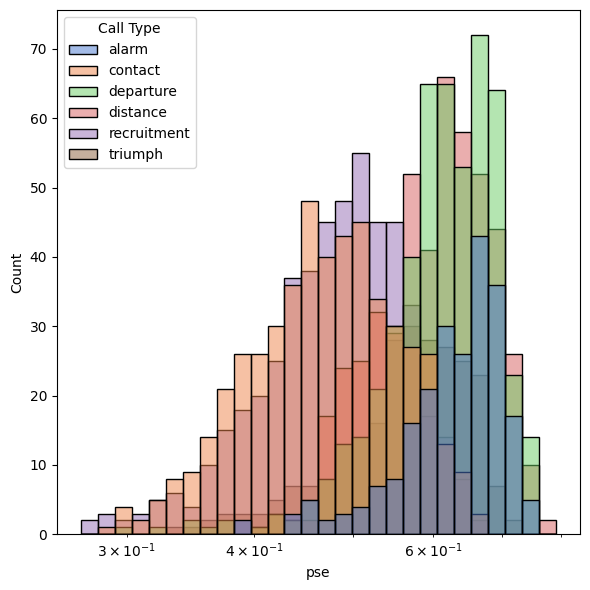

In [46]:
# TODO look into https://seaborn.pydata.org/examples/kde_ridgeplot.html
n_features = len(features_list)
n_columns = 3
n_rows = (n_features + n_columns - 1) // n_columns

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 6))


# Use KDE plots for ridge plot style
sns.histplot(
    data=calls_df, 
    x="pse",
    hue="Call Type", 
    fill=True, 
    common_norm=False,
    palette="muted", 
    linewidth=1,
    log_scale=True, 
    ax=ax
)
#ax.set_xlim()
# ax.set_title(plot_title)

plt.tight_layout()
plt.show()

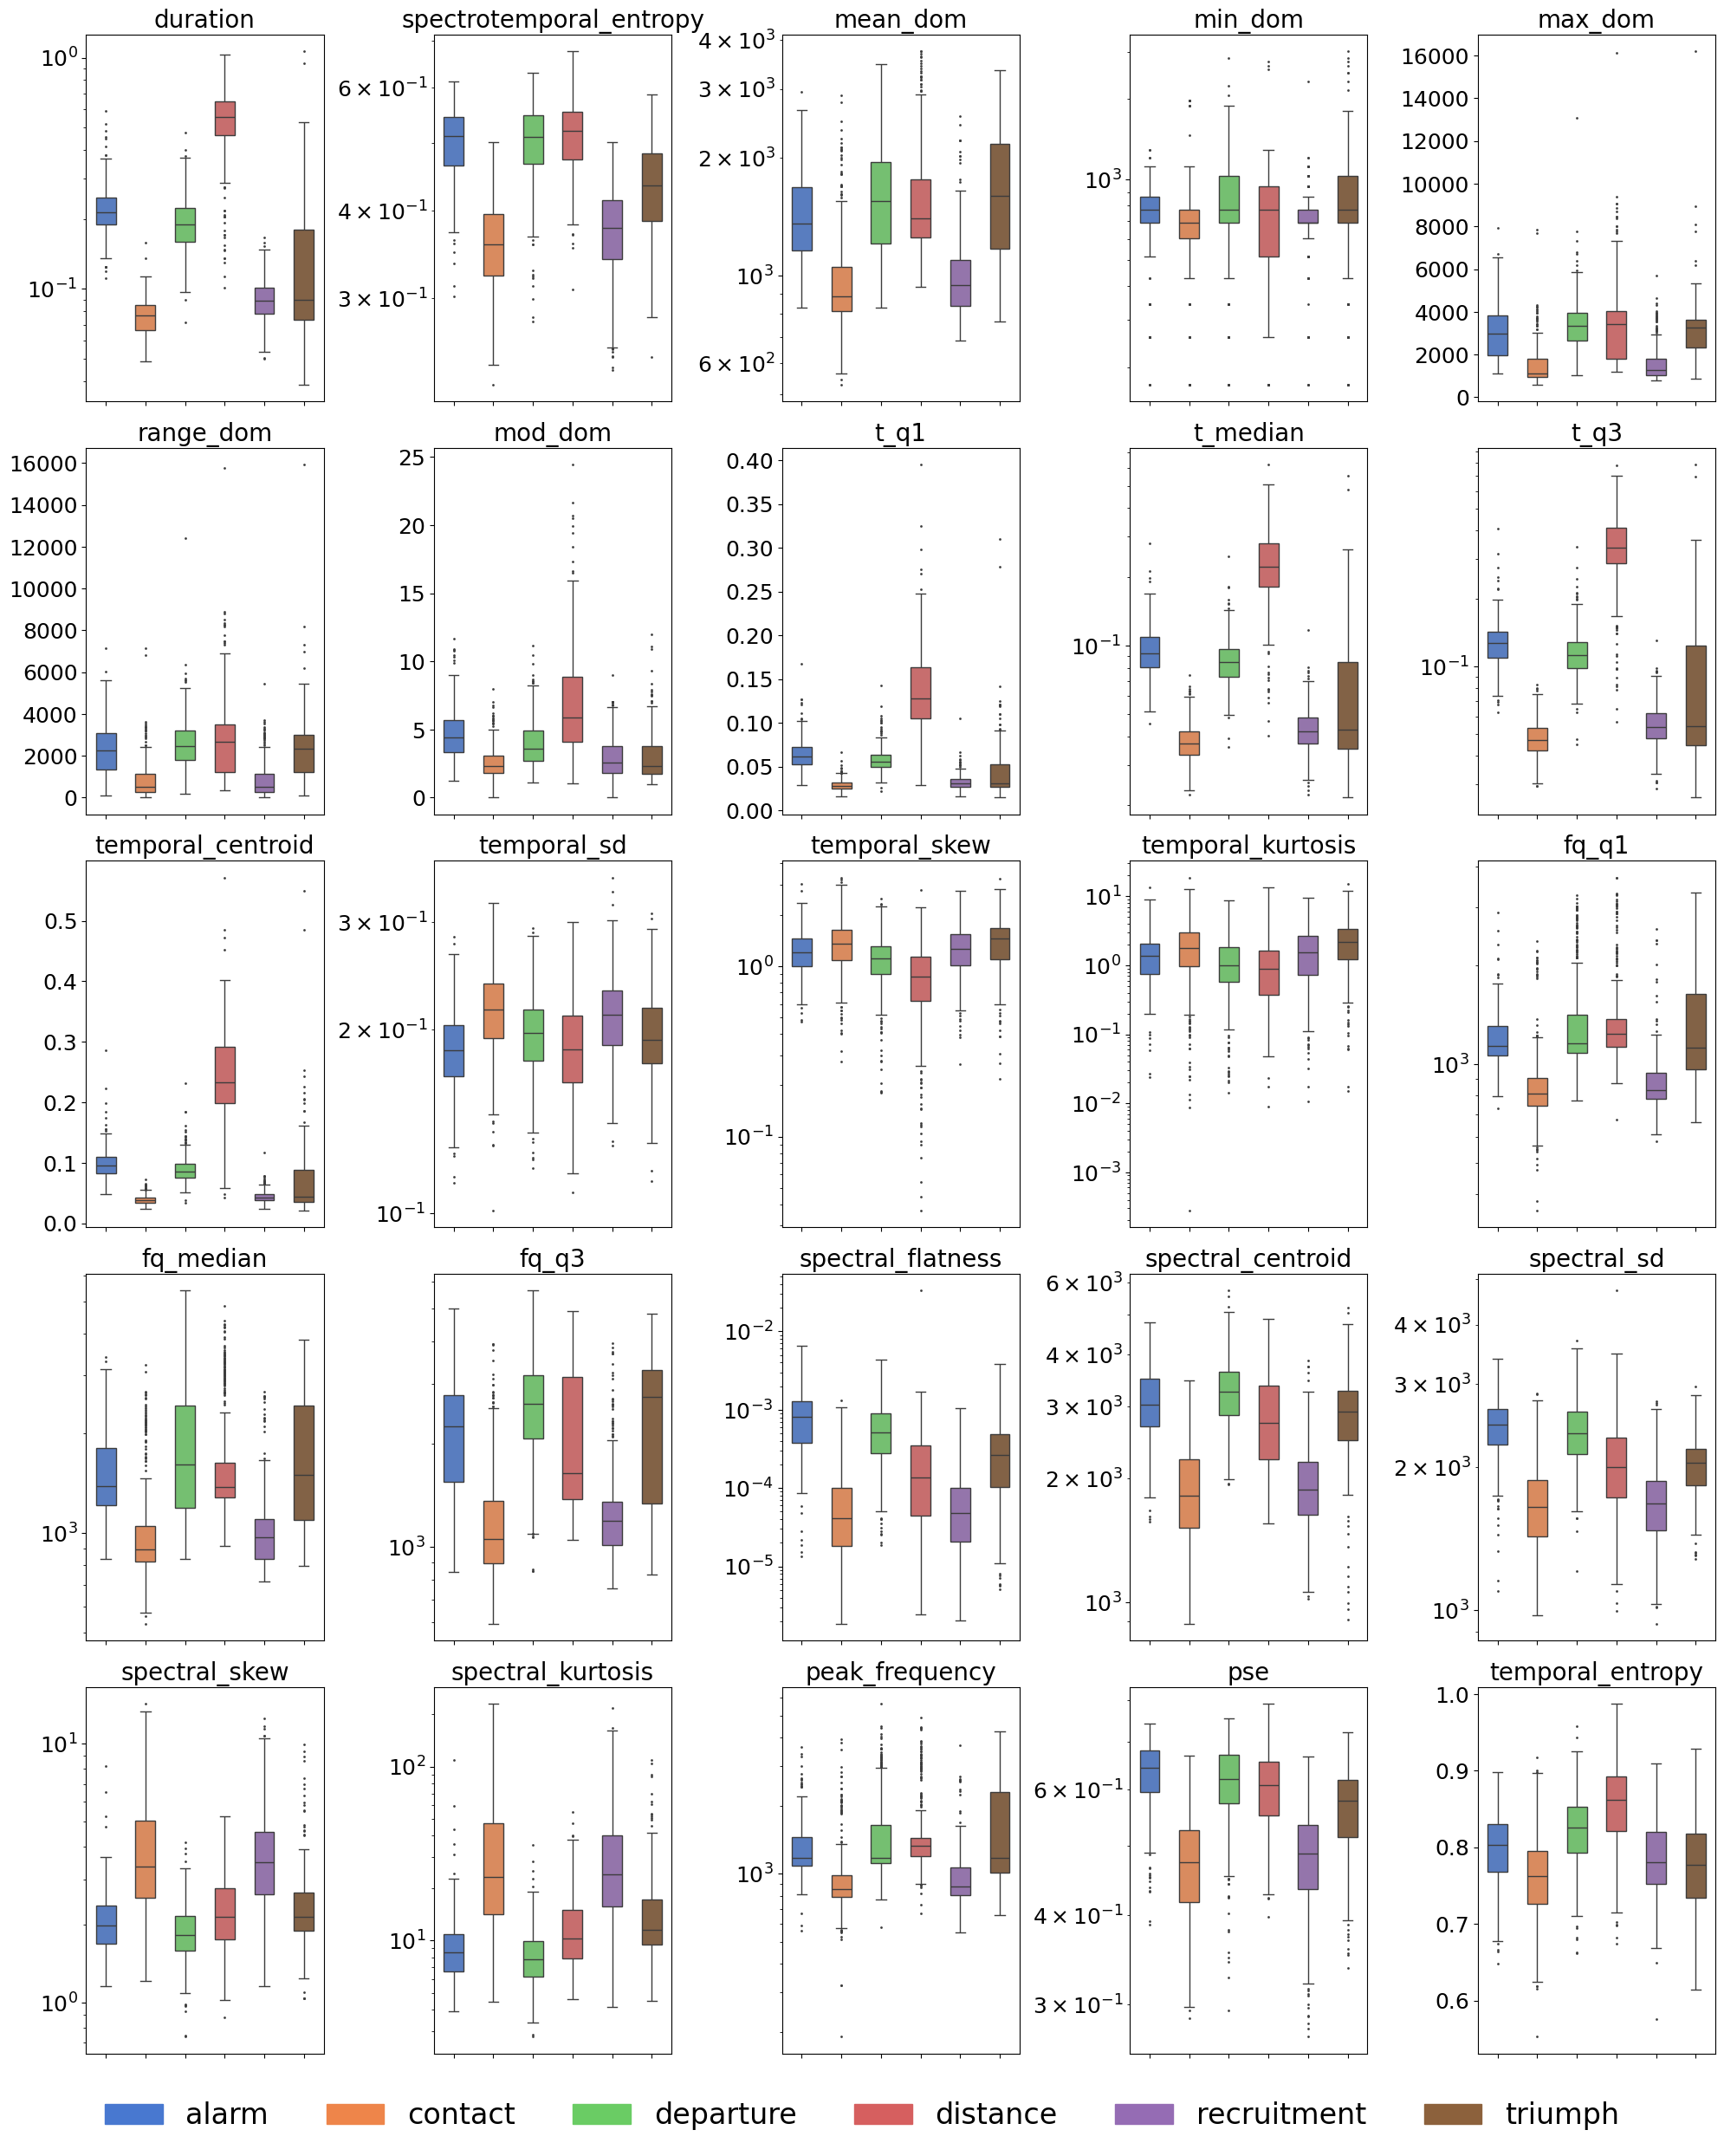

In [38]:
from matplotlib.patches import Patch

n_features = len(features_list)
n_columns = 5
n_rows = (n_features + n_columns - 1) // n_columns

unique_call_types = calls_df["Call Type"].unique()
color_palette = sns.color_palette("muted", len(unique_call_types))
label_to_color = {label: color for label, color in zip(unique_call_types, color_palette)}
legend_patches = [Patch(color=color, label=label) for label, color in label_to_color.items()]
colors = [label_to_color[label] for label in calls_df["Call Type"]]

fig, axes = plt.subplots(nrows=n_rows, ncols=n_columns, figsize=(4*n_columns, 5*n_rows))
axes = axes.flatten()

for i, (ax, feature, plot_title, log_scaled) in enumerate(zip(axes, features_list, feature_titles_list, log_feature)):
    try:
        sns.boxplot(
            data=calls_df, 
            y=feature,
            x="Call Type",
            hue="Call Type", 
            fill=True, 
            palette="muted",
            linewidth=1,
            log_scale=log_scaled, 
            ax=ax,
            width=1,
            gap=.5,
            fliersize=1,
            legend=False
        )
        ax.set_title(plot_title)
        ax.set_ylabel('')
        ax.set_xticklabels([])
        ax.set_xlabel('')

    except:
        continue

for j in range(n_features, len(axes)):
    axes[j].axis('off')

fig.legend(
    handles=legend_patches,
    loc='lower center',
    ncol=len(legend_patches), # one row
    fontsize=24,
    frameon=False,
)

plt.rcParams.update({
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'ytick.labelsize': 16,
})

plt.tight_layout()
fig.subplots_adjust(bottom=0.05)
plt.show()

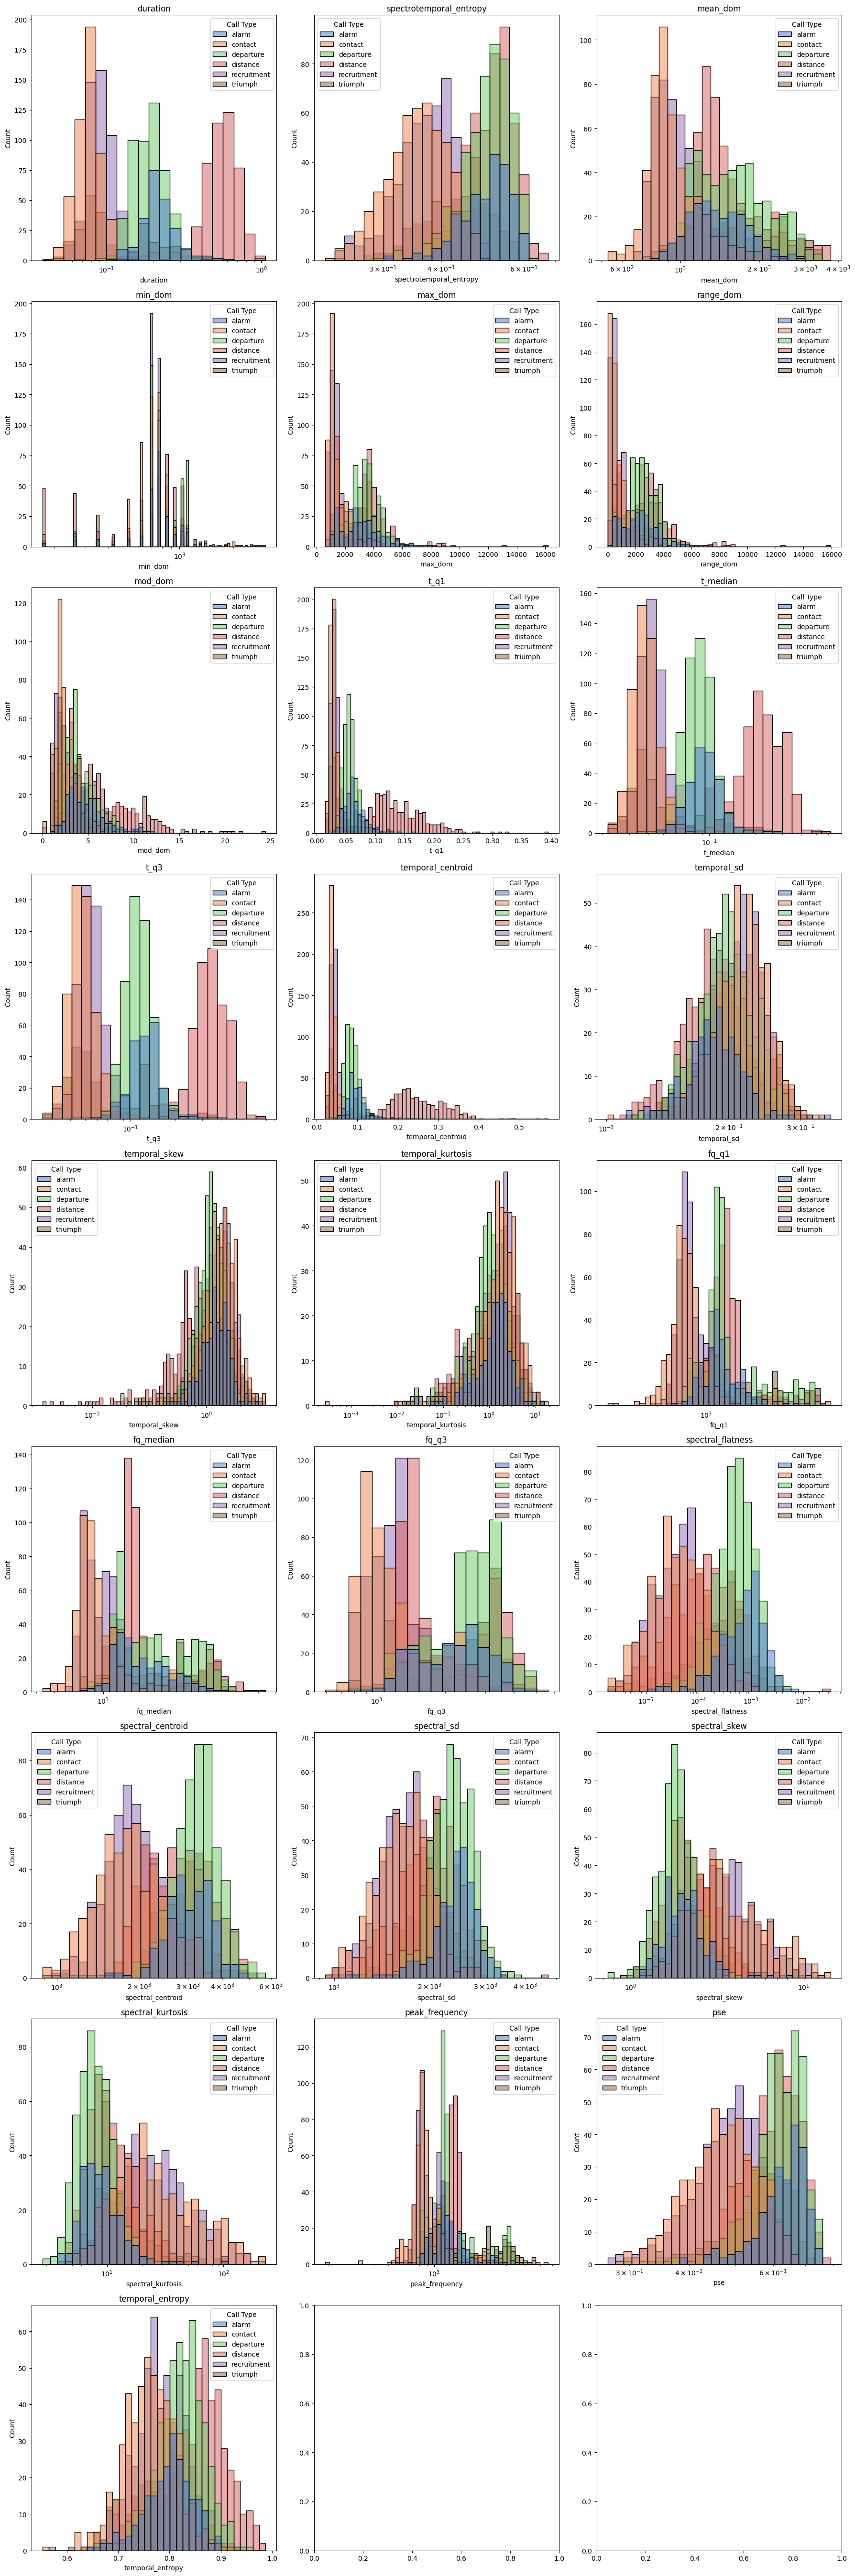

In [48]:
n_features = len(features_list)
n_columns = 3
n_rows = (n_features + n_columns - 1) // n_columns

fig, axes = plt.subplots(nrows=n_rows, ncols=n_columns, figsize=(6*n_columns, 6*n_rows))
axes = axes.flatten()

for ax, feature, plot_title, log_scaled in zip(axes, features_list, feature_titles_list, log_feature):
    try:
        # Use KDE plots for ridge plot style
        sns.histplot(
            data=calls_df, 
            x=feature,
            hue="Call Type", 
            fill=True, 
            common_norm=False,
            palette="muted", 
            linewidth=1,
            log_scale=log_scaled, 
            ax=ax
        )
        ax.set_xlabel(plot_title)
        ax.set_title(plot_title)
    except:
        continue

plt.tight_layout()
plt.show()


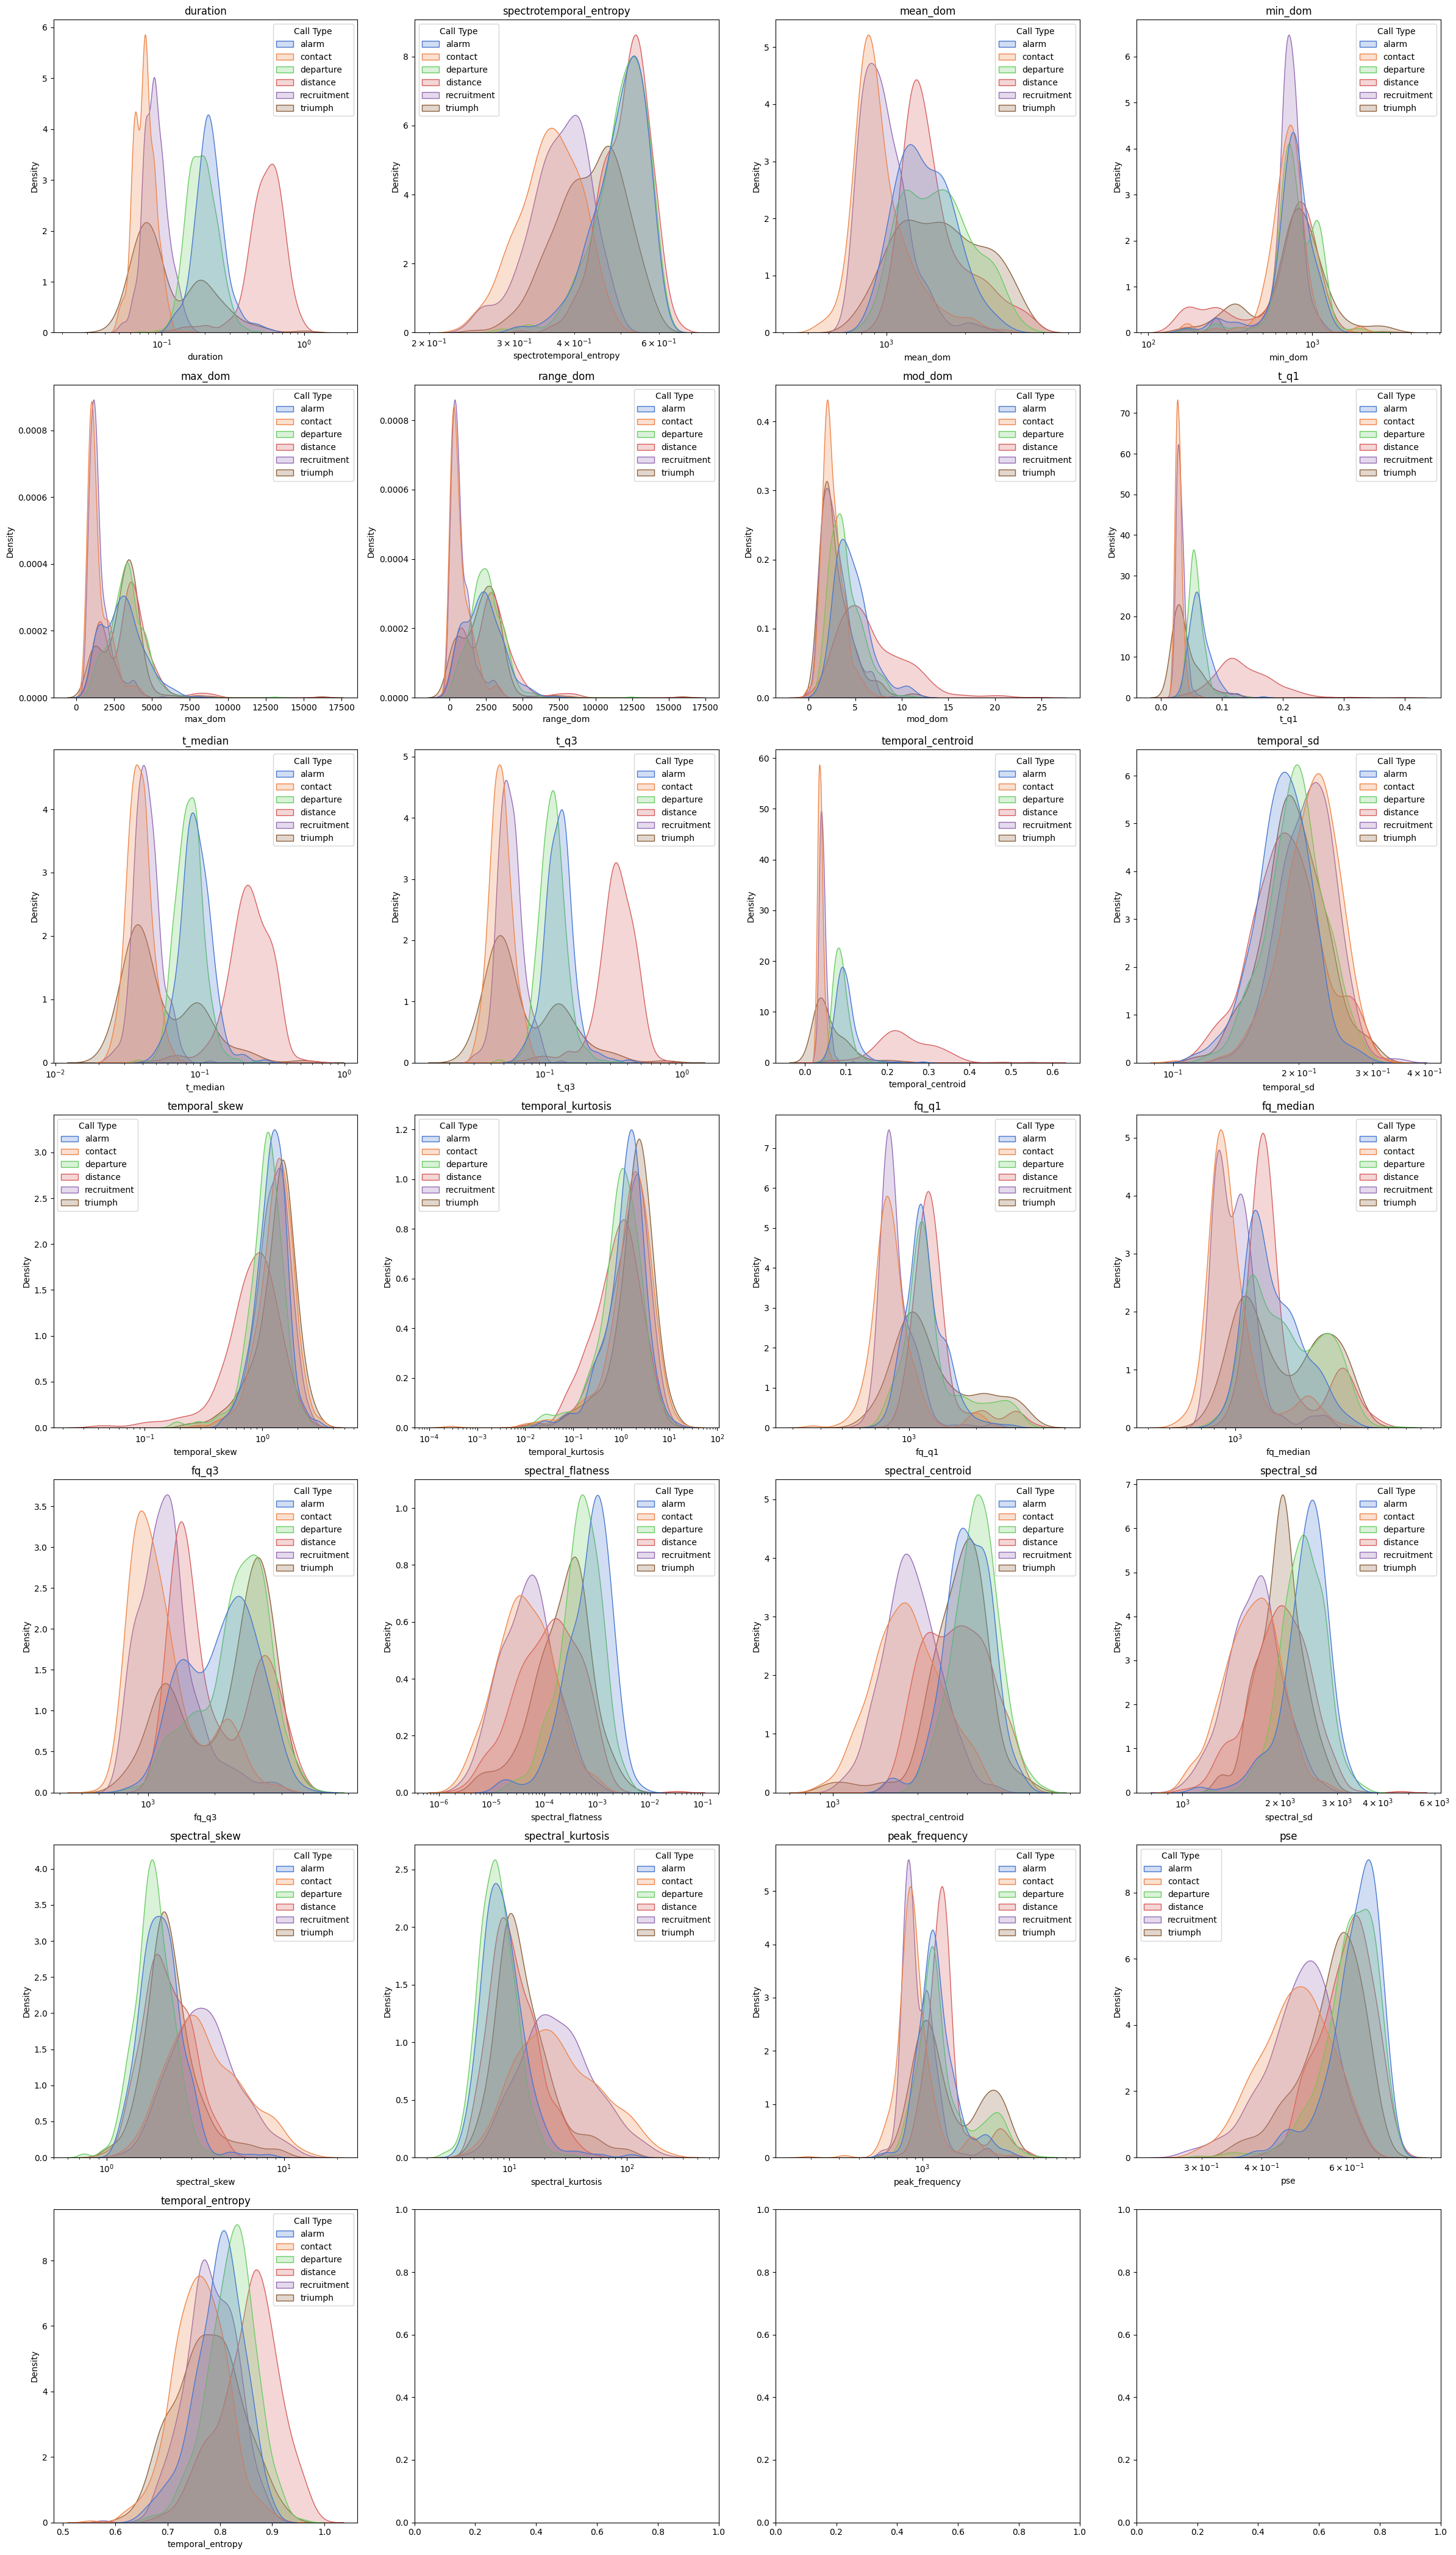

In [49]:
n_features = len(features_list)
n_columns = 4
n_rows = (n_features + n_columns - 1) // n_columns

fig, axes = plt.subplots(nrows=n_rows, ncols=n_columns, figsize=(6*n_columns, 6*n_rows))
axes = axes.flatten()

for ax, feature, plot_title, log_scaled in zip(axes, features_list, feature_titles_list, log_feature):
    try:
        # Use KDE plots for ridge plot style
        sns.kdeplot(
            data=calls_df, 
            x=feature,
            hue="Call Type", 
            fill=True, 
            common_norm=False,
            palette="muted", 
            linewidth=1,
            log_scale=log_scaled, 
            ax=ax
        )
        ax.set_xlabel(plot_title)
        ax.set_title(plot_title)
    except:
        continue

plt.tight_layout()
plt.show()


In [50]:
le = LabelEncoder()
y = le.fit_transform(calls_df["Call Type"])
X = calls_df[features_list].values
X_scaled = StandardScaler().fit_transform(X)
track_ids = calls_df['Track ID'].values

In [51]:
indices = np.arange(len(calls_df))

train_idxs, test_idxs, X_train, X_test, y_train, y_test = train_test_split(
    indices, X_scaled, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

In [52]:
param_grid = {
    'solver': ['svd', 'lsqr', 'eigen'],
    'shrinkage': ['auto', 0.0, 0.1, 0.5, 1.0],
    'n_components': [1, 2, 3]
}

cv = StratifiedGroupKFold(5, shuffle=True, random_state=RANDOM_SEED)
# GridSearchCV for LDA
grid_search = GridSearchCV(LDA(), param_grid, cv=cv, scoring='accuracy')
grid_search.fit(X_train, y_train, groups=track_ids[train_idxs])

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Evaluate on the test set
best_lda = grid_search.best_estimator_
y_pred = best_lda.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Best Parameters: {'n_components': 1, 'shrinkage': 0.0, 'solver': 'lsqr'}
Best Cross-Validation Accuracy: 0.6122936461032559
Test Accuracy: 0.6740890688259109


/Users/lena/Desktop/Master/Thesis/geese/code/GooseVocalizations/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
84 fits failed out of a total of 225.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
75 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/lena/Desktop/Master/Thesis/geese/code/GooseVocalizations/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/lena/Desktop/Master/Thesis/geese/code/GooseVocalizations/.venv/lib/python3.12/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)


In [53]:
lda = LDA(solver="lsqr", shrinkage=0, n_components=1)
lda.fit(X_train, y_train)

,solver,'lsqr'
,shrinkage,0
,priors,None
,n_components,1
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


              precision    recall  f1-score   support

       alarm       0.52      0.35      0.42        46
     contact       0.60      0.66      0.63       100
   departure       0.68      0.74      0.71       100
    distance       0.96      0.95      0.95        97
 recruitment       0.58      0.62      0.60       100
     triumph       0.56      0.45      0.50        51

    accuracy                           0.67       494
   macro avg       0.65      0.63      0.63       494
weighted avg       0.67      0.67      0.67       494



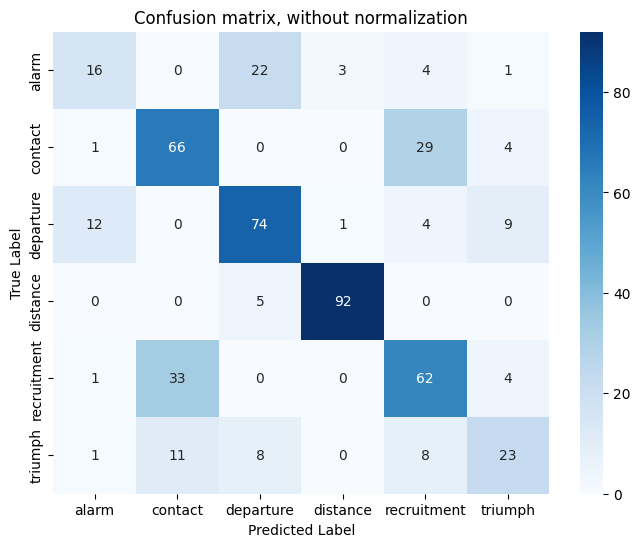

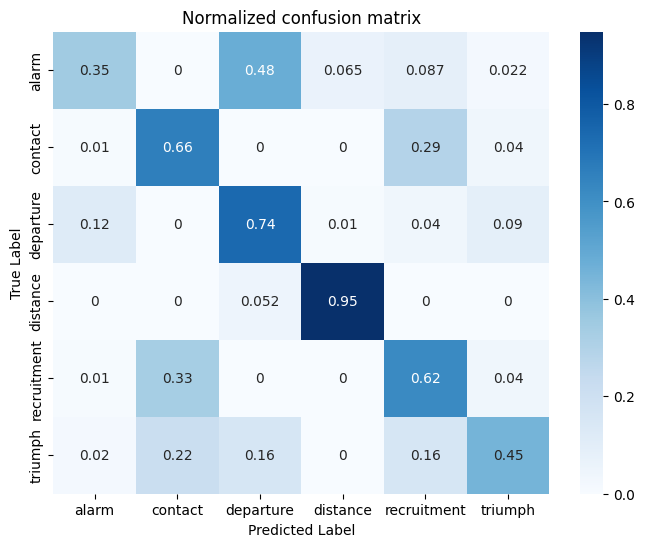

Feature coefficients per class:
   duration  spectrotemporal_entropy  mean_dom   min_dom   max_dom  range_dom  \
0  3.230447                -7.247191 -0.089583  0.182810  0.288878   0.255057   
1 -6.237535                 4.215877 -0.117483 -0.049787 -0.286711  -0.277866   
2  3.496221                -1.035997 -0.676505  0.103893  0.339639   0.320726   
3  7.684520                 2.735893  0.684766 -0.058497 -0.014765  -0.003806   
4 -4.599380                -1.096635 -0.008817 -0.144944 -0.233318  -0.206510   
5 -4.356187                -4.891087  0.789291  0.074546  0.027408   0.013457   

    mod_dom      t_q1   t_median      t_q3  ...  fq_median     fq_q3  \
0  0.280579  3.407816   0.943284 -1.292311  ...  -0.409452 -0.926142   
1 -0.118590 -2.019916   3.065822 -0.897827  ...   0.441290  0.386092   
2  0.165564  1.913980   2.871967 -1.219469  ...  -0.110334 -0.485369   
3 -0.101127  1.099983 -10.357205  4.198215  ...   0.001786 -0.199238   
4  0.076119 -1.040788   2.782863 -1.4412

In [54]:
y_pred = lda.predict(X_test)
create_evaluation_plots(y_test, y_pred, le)
coef_df = pd.DataFrame(lda.coef_, columns=features_list, index=lda.classes_)
print("Feature coefficients per class:")
print(coef_df)

In [55]:
abs_coef = coef_df.abs().mean(axis=0)
print("Feature Importance Ranking:")
print(abs_coef.sort_values(ascending=False))

Feature Importance Ranking:
temporal_centroid          5.121292
duration                   4.934048
pse                        3.770409
t_median                   3.753411
spectrotemporal_entropy    3.537113
spectral_centroid          2.270302
t_q1                       2.158655
temporal_entropy           1.763671
t_q3                       1.602988
spectral_skew              1.501382
spectral_kurtosis          1.149927
spectral_sd                0.949232
temporal_skew              0.617346
temporal_kurtosis          0.544633
fq_q3                      0.538967
fq_q1                      0.520013
mean_dom                   0.394408
temporal_sd                0.275134
fq_median                  0.237715
max_dom                    0.198453
mod_dom                    0.185021
range_dom                  0.179570
peak_frequency             0.143809
spectral_flatness          0.119427
min_dom                    0.102413
dtype: float64


In [56]:
abs_coef.sort_values(ascending=False).to_dict().keys()

dict_keys(['temporal_centroid', 'duration', 'pse', 't_median', 'spectrotemporal_entropy', 'spectral_centroid', 't_q1', 'temporal_entropy', 't_q3', 'spectral_skew', 'spectral_kurtosis', 'spectral_sd', 'temporal_skew', 'temporal_kurtosis', 'fq_q3', 'fq_q1', 'mean_dom', 'temporal_sd', 'fq_median', 'max_dom', 'mod_dom', 'range_dom', 'peak_frequency', 'spectral_flatness', 'min_dom'])

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_84821/1891333542.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(calls_df["Call Type"].unique(), rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_84821/1891333542.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(calls_df["Call Type"].unique(), rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_84821/1891333542.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(calls_df["Call Type"].unique(), rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_84821/1891333542.py:28: UserWarning: set_ticklabels() should only be used 

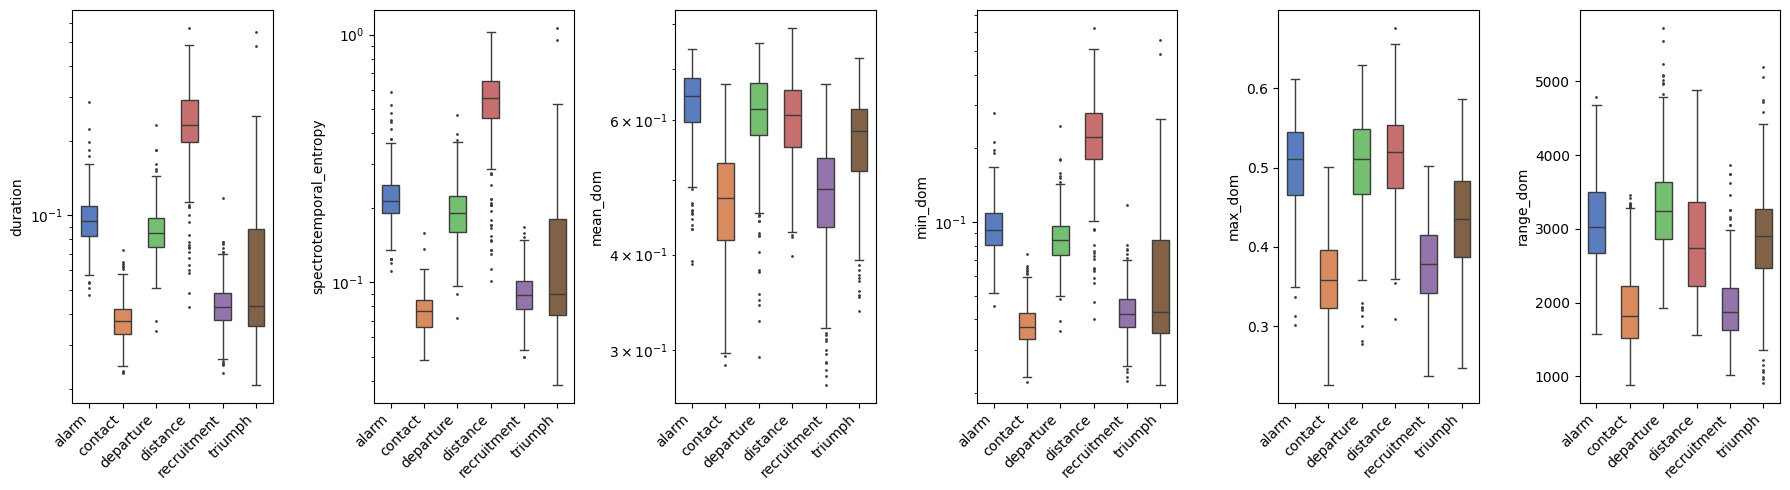

In [57]:
n_features = 6
n_columns = 6
n_rows = (n_features + n_columns - 1) // n_columns

fig, axes = plt.subplots(nrows=n_rows, ncols=n_columns, figsize=(3*n_columns, 5*n_rows))
axes = axes.flatten()

ranking_list = list(abs_coef.sort_values(ascending=False).to_dict().keys())
for ax, feature, plot_title, log_scaled in zip(axes, ranking_list[:n_features], feature_titles_list, log_feature):
    try:
        # Use KDE plots for ridge plot style
        sns.boxplot(
            data=calls_df, 
            y=feature,
            x="Call Type",
            hue="Call Type", 
            fill=True, 
            palette="muted", 
            linewidth=1,
            log_scale=log_scaled, 
            ax=ax,
            width=1,
            gap=.5,
            fliersize=1,
            legend=False
        )
        ax.set_ylabel(plot_title)
        ax.set_xticklabels(calls_df["Call Type"].unique(), rotation=45, ha='right')
        ax.set_xlabel("")
        #ax.set_title(plot_title)
    except:
        continue

plt.tight_layout()
plt.show()

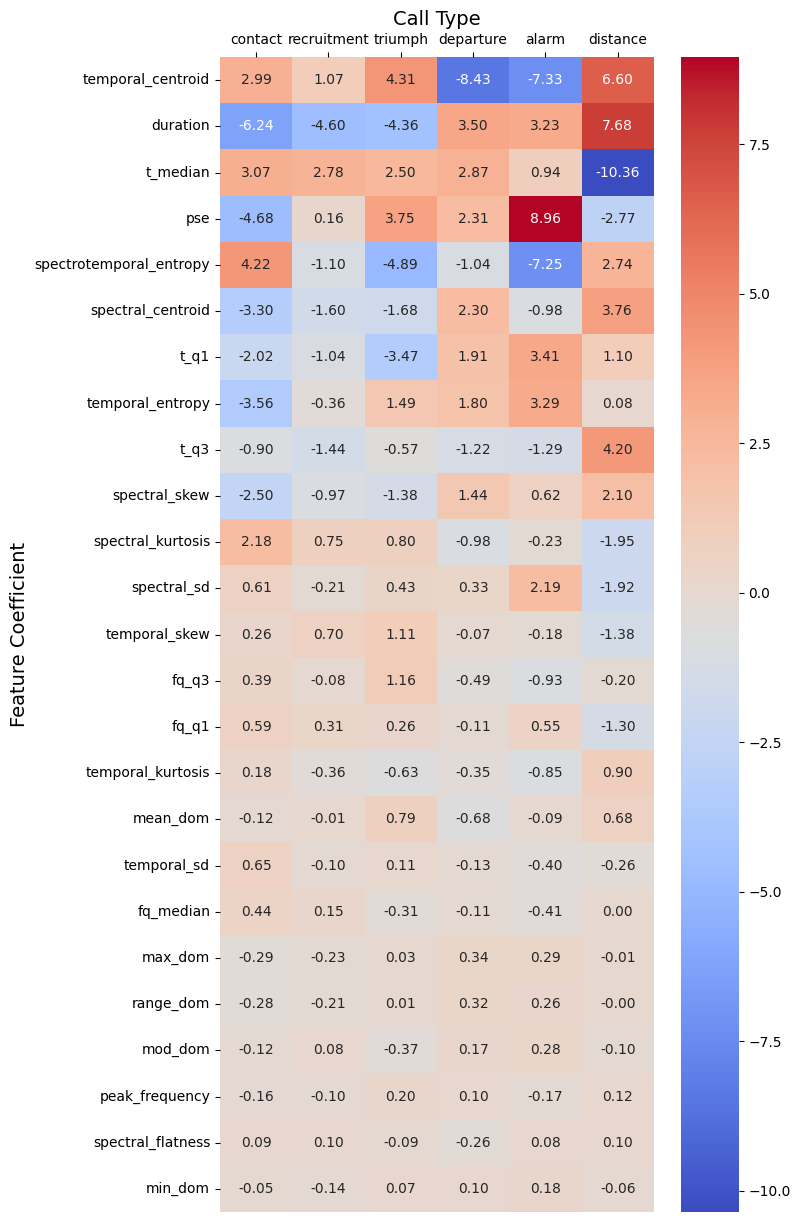

In [58]:
sorted_call_types = [1, 4, 5, 2, 0, 3]

coef_df_sorted_by_rows = coef_df.loc[sorted_call_types]


# Calculate the variance of the coefficients for each feature across all classes
coef_variance = coef_df.var(axis=0)

# Sort the features by the variance in descending order (most variance first)
sorted_features = coef_variance.sort_values(ascending=False).index

# Reorder the coef_df DataFrame by sorted rows (call types) and sorted columns (features)
coef_df_sorted_by_rows_and_columns = coef_df_sorted_by_rows[sorted_features]
coef_df_transposed = coef_df_sorted_by_rows_and_columns.T

# Visualize the sorted feature coefficients
plt.figure(figsize=(7, 15))
ax = sns.heatmap(coef_df_transposed, annot=True, cmap='coolwarm', fmt=".2f", cbar=True, xticklabels=le.inverse_transform(coef_df_sorted_by_rows_and_columns.index))
#plt.title('Feature Coefficients per Call Type')
ax.xaxis.set_ticks_position('top')

plt.title('Call Type', fontsize=14)
plt.ylabel('Feature Coefficient', fontsize=14)
plt.xlabel('')
plt.show()


Perform permutation test

https://scikit-learn.org/1.5/auto_examples/model_selection/plot_permutation_tests_for_classification.html#sphx-glr-auto-examples-model-selection-plot-permutation-tests-for-classification-py

In [59]:
cv = StratifiedGroupKFold(5, shuffle=True, random_state=RANDOM_SEED)
lda = LDA(solver="lsqr", shrinkage=0, n_components=1)

In [60]:
score, permutation_scores, pvalue = permutation_test_score(
    lda, X_scaled, y, random_state=RANDOM_SEED, cv=cv, n_permutations=500, groups=calls_df['Track ID']
)

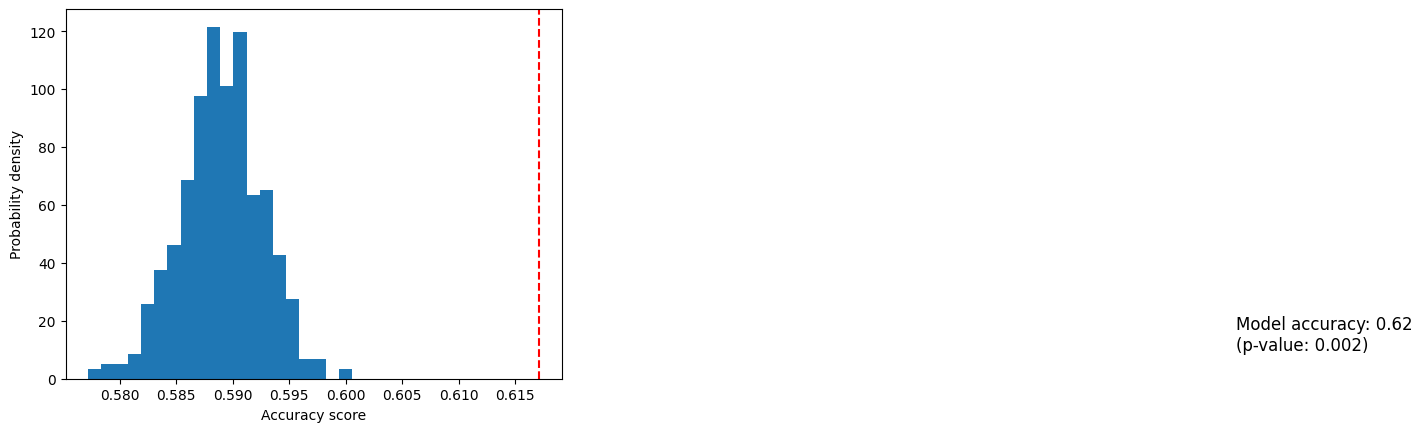

In [61]:
fig, ax = plt.subplots()

ax.hist(permutation_scores, bins=20, density=True)
ax.axvline(score, ls="--", color="r")
score_label = f"Model accuracy: {score:.2f}\n(p-value: {pvalue:.3f})"
ax.text(score*1.1, 10, score_label, fontsize=12)
ax.set_xlabel("Accuracy score")
ax.set_ylabel("Probability density")
plt.show()

In [62]:
# simulate chance level
true_labels = calls_df["Call Type"]
class_probs = true_labels.value_counts(normalize=True)
random_predictions = np.random.choice(class_probs.index, size=len(true_labels), p=class_probs.values)

# Calculate accuracy for random guessing
random_accuracy = accuracy_score(true_labels, random_predictions)

print("Chance Level (Random Guessing):", random_accuracy)


Chance Level (Random Guessing): 0.1909201459262262


#### VAE representations

In [63]:
X = np.array(calls_df["latent_representation"].tolist())
X_scaled = StandardScaler().fit_transform(X)
train_idxs, test_idxs, X_train, X_test, y_train, y_test = train_test_split(
    indices, X_scaled, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

In [64]:
X.shape

(2467, 128)

In [65]:
lda = LDA(solver="lsqr", shrinkage=0, n_components=1)
lda.fit(X_train, y_train)

,solver,'lsqr'
,shrinkage,0
,priors,None
,n_components,1
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


              precision    recall  f1-score   support

       alarm       0.33      0.24      0.28        46
     contact       0.59      0.65      0.62       100
   departure       0.59      0.75      0.66       100
    distance       0.92      0.96      0.94        97
 recruitment       0.61      0.60      0.60       100
     triumph       0.38      0.18      0.24        51

    accuracy                           0.63       494
   macro avg       0.57      0.56      0.56       494
weighted avg       0.61      0.63      0.62       494



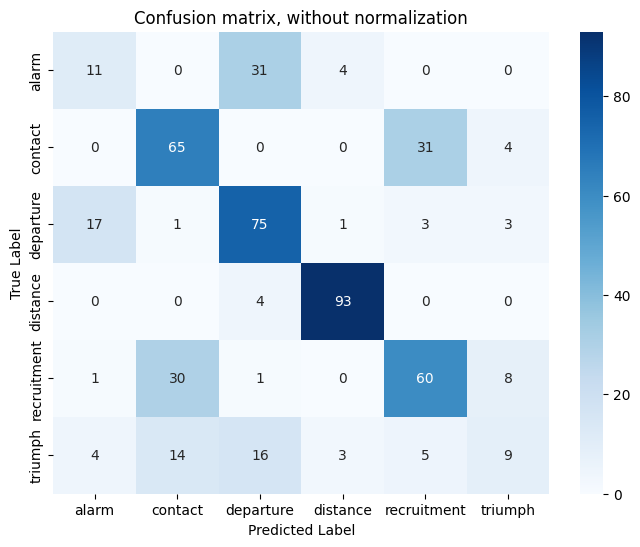

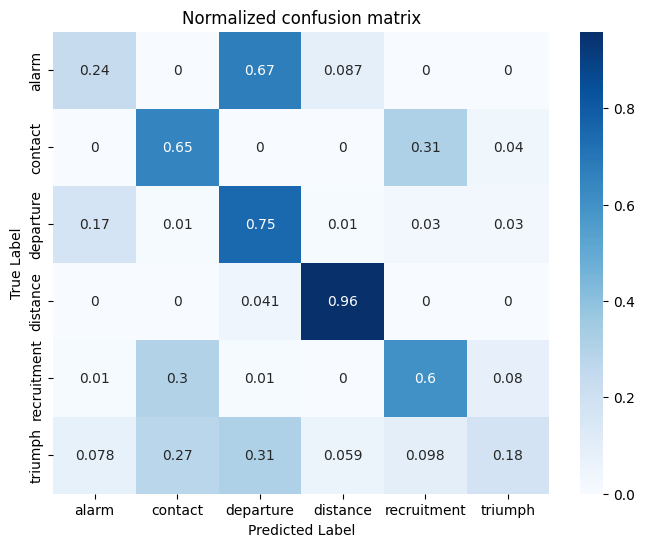

In [66]:
y_pred = lda.predict(X_test)
create_evaluation_plots(y_test, y_pred, le)

In [67]:
cv = StratifiedGroupKFold(5, shuffle=True, random_state=RANDOM_SEED)
lda = LDA(solver="lsqr", shrinkage=0, n_components=1)

In [68]:
score, permutation_scores, pvalue = permutation_test_score(
    lda, X_scaled, y, random_state=RANDOM_SEED, cv=cv, n_permutations=500, groups=calls_df['Track ID']
)

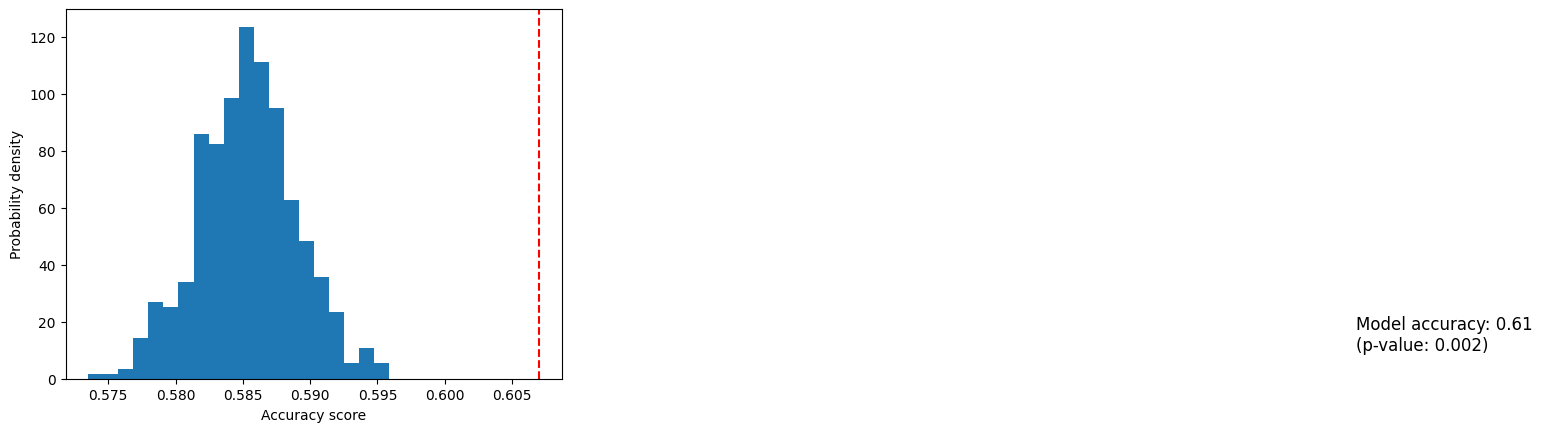

In [69]:
fig, ax = plt.subplots()

ax.hist(permutation_scores, bins=20, density=True)
ax.axvline(score, ls="--", color="r")
score_label = f"Model accuracy: {score:.2f}\n(p-value: {pvalue:.3f})"
ax.text(score*1.1, 10, score_label, fontsize=12)
ax.set_xlabel("Accuracy score")
ax.set_ylabel("Probability density")
plt.show()

## MLP

## CNN

In [70]:
from torchvision.transforms import Compose, Lambda, Resize

In [71]:
LEARNING_RATE = 1e-4
BATCH_SIZE = 32
N_EPOCHS = 30

In [72]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


In [73]:
# data augmentation
image_transforms = Compose([
    Lambda(lambda img: torch.roll(img, shifts=random.randint(-40, 40), dims=-1)), # Random shift
    #Lambda(lambda spec: Normalize(spec)), 
])

#### LFCCs

In [74]:
le = LabelEncoder()
le.fit(calls_df["Call Type"])
calls_df["encoded_call_type"] = le.transform(calls_df["Call Type"])

In [75]:
lfccs_flat = np.array([x.flatten() for x in calls_df['log_padded_lfccs']]) 

scaler = StandardScaler()
lfccs_scaled = scaler.fit_transform(lfccs_flat)

# Reshape to original dimensions
n_samples, height, width = len(calls_df), calls_df['log_padded_lfccs'][0].shape[0], calls_df['log_padded_lfccs'][0].shape[1]
lfccs_scaled = lfccs_scaled.reshape(n_samples, height, width)  

# Assign the scaled features back to the DataFrame if needed
calls_df['log_padded_lfccs_scaled'] = list(lfccs_scaled)

In [76]:
class LFCCDataset(Dataset):
    def __init__(self, df, transform=True):
        self.df = df
        self.groups = df["Track ID"]
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.df.iloc[idx]["log_padded_lfccs_scaled"]).to(torch.float32).to(device)
        x = x[np.newaxis, ...] # Add channel dimension -> Shape: (1, 16, 215)
        if self.transform:
            x = image_transforms(x)
        return x, self.df.iloc[idx]["encoded_call_type"]

ds_lfcc = LFCCDataset(calls_df)

num_items = len(ds_lfcc)
num_train = round(num_items * 0.8)
num_val = round(num_items * 0.1)
num_test = num_items - num_train - num_val
train_ds, val_ds, test_ds = random_split(ds_lfcc, [num_train, num_val, num_test])

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [77]:
train_features, train_labels = next(iter(train_dl))
print(f"Feature batch shape: {train_features.size()}")

input_size=train_features.size()[1:]
print(input_size[1], input_size[2])

Feature batch shape: torch.Size([32, 1, 16, 23])
16 23


In [78]:
class LFCCCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.layers = torch.nn.Sequential( # (1, 16, 23)
            nn.Conv2d(1, 32, kernel_size=(3, 3), padding=1), # (32, 16, 23)
            nn.MaxPool2d(kernel_size=(2, 2)), # (32, 8, 11)
            nn.Conv2d(32, 64, kernel_size=(3, 3), padding=1), # (64, 8, 11)
            nn.Flatten(),
            nn.Linear(64 * 8 * 11, 128),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.layers(x)
        return x

In [79]:
# Instantiate model
n_classes = 6
model = LFCCCNN(n_classes)

# Loss and Optimizer
loss_criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
model.to(device)

# Train
n_epochs = N_EPOCHS
train_model(model, n_epochs, train_dl, device, optimizer, loss_criterion)

# Evaluate
val_targets, val_predictions, _ = test_model(model, val_dl, device)
print(f"Validation Accuracy: {accuracy_score(val_targets, val_predictions):.4f}")

Epoch 1/30, Loss: 1.2043
Epoch 2/30, Loss: 1.0596
Epoch 3/30, Loss: 0.9868
Epoch 4/30, Loss: 0.9576
Epoch 5/30, Loss: 0.9293
Epoch 6/30, Loss: 0.9037
Epoch 7/30, Loss: 0.8835
Epoch 8/30, Loss: 0.8499
Epoch 9/30, Loss: 0.8280
Epoch 10/30, Loss: 0.8170
Epoch 11/30, Loss: 0.8073
Epoch 12/30, Loss: 0.7932
Epoch 13/30, Loss: 0.7790
Epoch 14/30, Loss: 0.7689
Epoch 15/30, Loss: 0.7575
Epoch 16/30, Loss: 0.7471
Epoch 17/30, Loss: 0.7348
Epoch 18/30, Loss: 0.7401
Epoch 19/30, Loss: 0.7287
Epoch 20/30, Loss: 0.7221
Epoch 21/30, Loss: 0.7194
Epoch 22/30, Loss: 0.7042
Epoch 23/30, Loss: 0.6979
Epoch 24/30, Loss: 0.7025
Epoch 25/30, Loss: 0.6958
Epoch 26/30, Loss: 0.6854
Epoch 27/30, Loss: 0.6851
Epoch 28/30, Loss: 0.6757
Epoch 29/30, Loss: 0.6799
Epoch 30/30, Loss: 0.6718
Validation Accuracy: 0.6599


              precision    recall  f1-score   support

       alarm       0.59      0.50      0.54        26
     contact       0.62      0.37      0.46        57
   departure       0.77      0.71      0.73        51
    distance       0.95      0.89      0.92        45
 recruitment       0.51      0.72      0.60        54
     triumph       0.40      0.77      0.53        13

    accuracy                           0.65       246
   macro avg       0.64      0.66      0.63       246
weighted avg       0.67      0.65      0.64       246



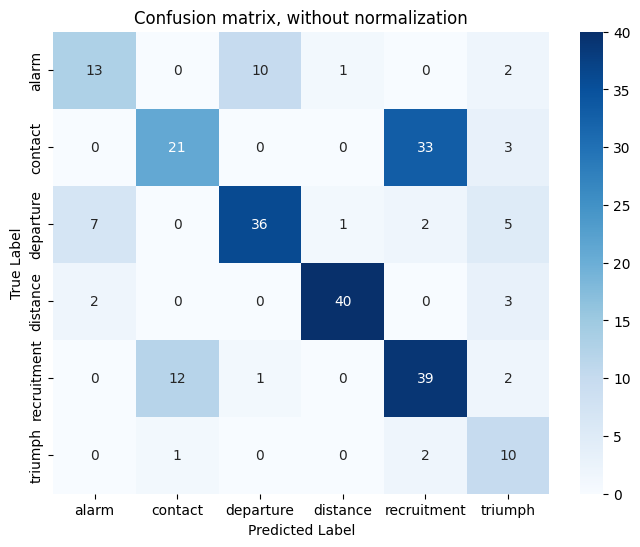

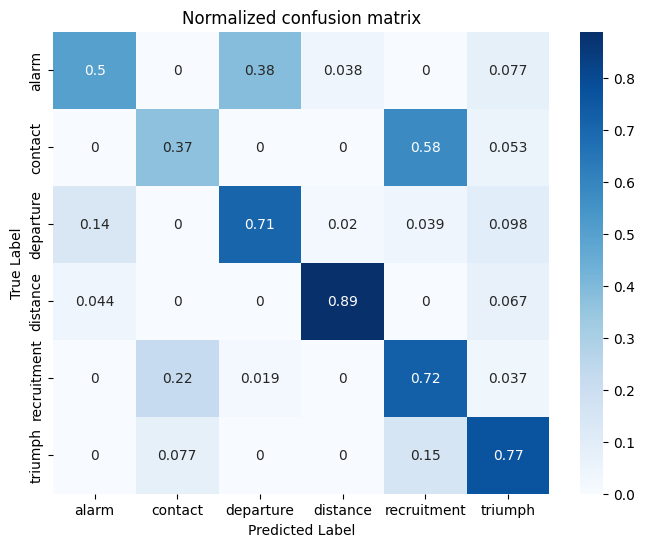

In [80]:
evaluate_model(model, test_dl, device, le, num_classes=6)

#### Spectrograms

In [81]:
specs_flat = np.array([x.flatten() for x in calls_df['log_padded_spectrogram']]) 

scaler = StandardScaler()
specs_scaled = scaler.fit_transform(specs_flat)

# Reshape to original dimensions
n_samples, height, width = len(calls_df), calls_df['log_padded_spectrogram'][0].shape[0], calls_df['log_padded_spectrogram'][0].shape[1]
specs_scaled = specs_scaled.reshape(n_samples, height, width)  

# Assign the scaled features back to the DataFrame if needed
calls_df['log_padded_spectrogram_scaled'] = list(specs_scaled)

In [82]:
class SpecDataset(Dataset):
    def __init__(self, df, transform=True):
        self.df = df
        self.groups = df["Track ID"]
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.df.iloc[idx]["log_padded_spectrogram_scaled"]).to(torch.float32).to(device) # Shape: (n_samples, 16, 215)
        x = x[np.newaxis, ...] # Add channel dimension -> Shape: (1, 16, 215)
        if self.transform:
            x = image_transforms(x)
        return x, self.df.iloc[idx]["encoded_call_type"]

ds_spec = SpecDataset(calls_df)

num_items = len(ds_spec)
num_train = round(num_items * 0.7)
num_val = round(num_items * 0.15)
num_test = num_items - num_train - num_val
train_ds, val_ds, test_ds = random_split(ds_spec, [num_train, num_val, num_test])

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [83]:
train_features, train_labels = next(iter(train_dl))
print(f"Feature batch shape: {train_features.size()}")

input_size=train_features.size()[1:]
print(input_size[1], input_size[2])

Feature batch shape: torch.Size([32, 1, 25, 201])
25 201


In [84]:
class SpecCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.layers = torch.nn.Sequential( # (1, 25, 201)
            nn.Conv2d(1, 16, kernel_size=(3, 3), padding=1), # (16, 25, 201)
            nn.MaxPool2d(kernel_size=(2, 2)), # (16, 12, 100)
            nn.Conv2d(16, 32, kernel_size=(3, 3), padding=1), # (32, 12, 100)
            nn.Flatten(),
            nn.Linear(32 * 12 * 100, 128),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.layers(x)
        return x

In [85]:
# Instantiate model
n_classes = 6
model = SpecCNN(n_classes)

# Loss and Optimizer
loss_criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
model.to(device)

# Train
n_epochs = N_EPOCHS
train_model(model, n_epochs, train_dl, device, optimizer, loss_criterion)

# Evaluate
val_targets, val_predictions, _ = test_model(model, val_dl, device)
print(f"Validation Accuracy: {accuracy_score(val_targets, val_predictions):.4f}")

Epoch 1/30, Loss: 1.1519
Epoch 2/30, Loss: 0.8696
Epoch 3/30, Loss: 0.8490
Epoch 4/30, Loss: 0.8153
Epoch 5/30, Loss: 0.7318
Epoch 6/30, Loss: 0.7296
Epoch 7/30, Loss: 0.7361
Epoch 8/30, Loss: 0.7024
Epoch 9/30, Loss: 0.7025
Epoch 10/30, Loss: 0.7304
Epoch 11/30, Loss: 0.6668
Epoch 12/30, Loss: 0.6669
Epoch 13/30, Loss: 0.6533
Epoch 14/30, Loss: 0.6710
Epoch 15/30, Loss: 0.6652
Epoch 16/30, Loss: 0.6626
Epoch 17/30, Loss: 0.6398
Epoch 18/30, Loss: 0.6385
Epoch 19/30, Loss: 0.6110
Epoch 20/30, Loss: 0.5994
Epoch 21/30, Loss: 0.6135
Epoch 22/30, Loss: 0.6086
Epoch 23/30, Loss: 0.6361
Epoch 24/30, Loss: 0.6073
Epoch 25/30, Loss: 0.6009
Epoch 26/30, Loss: 0.5843
Epoch 27/30, Loss: 0.5972
Epoch 28/30, Loss: 0.5912
Epoch 29/30, Loss: 0.5828
Epoch 30/30, Loss: 0.5737
Validation Accuracy: 0.7486


              precision    recall  f1-score   support

       alarm       0.62      0.48      0.54        42
     contact       0.65      0.84      0.73        63
   departure       0.73      0.81      0.77        75
    distance       0.99      0.92      0.95        85
 recruitment       0.74      0.70      0.72        69
     triumph       0.59      0.47      0.52        36

    accuracy                           0.75       370
   macro avg       0.72      0.70      0.71       370
weighted avg       0.75      0.75      0.75       370



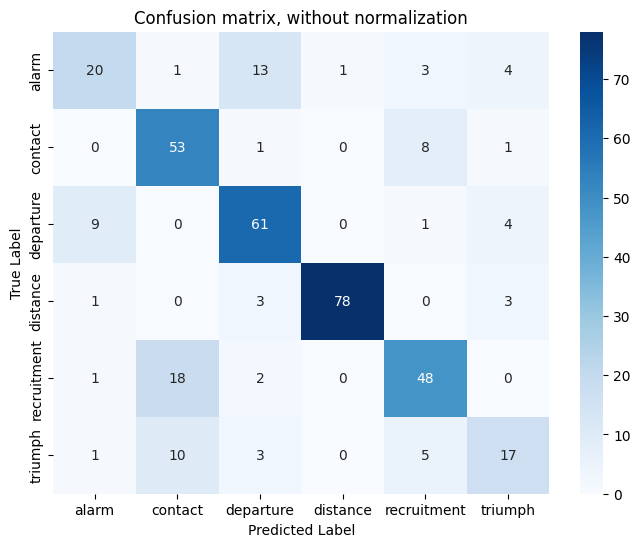

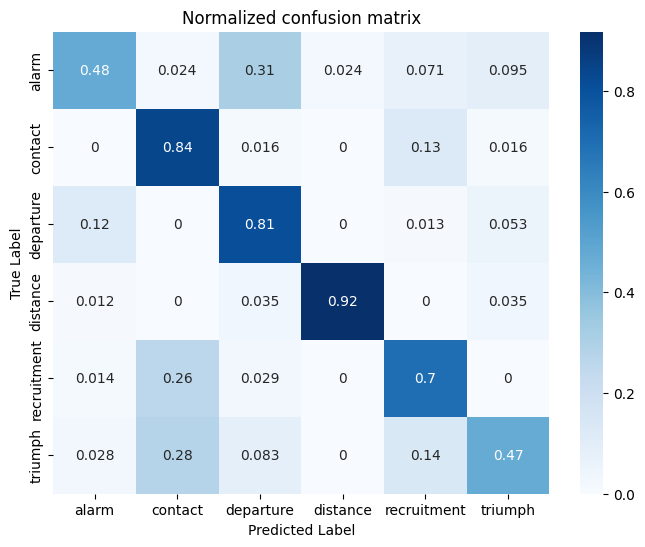

In [86]:
evaluate_model(model, test_dl, device, le, num_classes=6)


--- Fold 1 ---
Epoch 1/35, Loss: 1.0571
Epoch 2/35, Loss: 0.8540
Epoch 3/35, Loss: 0.7840
Epoch 4/35, Loss: 0.8226
Epoch 5/35, Loss: 0.7193
Epoch 6/35, Loss: 0.7259
Epoch 7/35, Loss: 0.7168
Epoch 8/35, Loss: 0.6921
Epoch 9/35, Loss: 0.6949
Epoch 10/35, Loss: 0.6890
Epoch 11/35, Loss: 0.6873
Epoch 12/35, Loss: 0.6715
Epoch 13/35, Loss: 0.6669
Epoch 14/35, Loss: 0.6544
Epoch 15/35, Loss: 0.6668
Epoch 16/35, Loss: 0.6402
Epoch 17/35, Loss: 0.6541
Epoch 18/35, Loss: 0.6197
Epoch 19/35, Loss: 0.6767
Epoch 20/35, Loss: 0.6443
Epoch 21/35, Loss: 0.6347
Epoch 22/35, Loss: 0.6291
Epoch 23/35, Loss: 0.6372
Epoch 24/35, Loss: 0.6122
Epoch 25/35, Loss: 0.6171
Epoch 26/35, Loss: 0.6132
Epoch 27/35, Loss: 0.6126
Epoch 28/35, Loss: 0.5999
Epoch 29/35, Loss: 0.6149
Epoch 30/35, Loss: 0.5974
Epoch 31/35, Loss: 0.6222
Epoch 32/35, Loss: 0.5968
Epoch 33/35, Loss: 0.6075
Epoch 34/35, Loss: 0.5981
Epoch 35/35, Loss: 0.5903

Validation Accuracy for Fold 1: 0.7096
  Micro-averaged One-vs-Rest ROC AUC score:

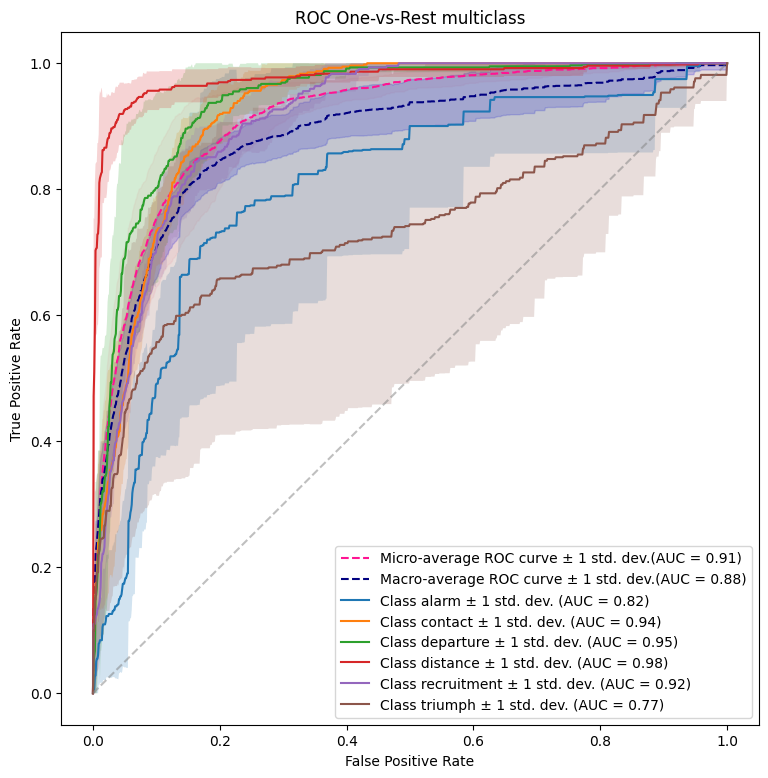

In [87]:
summary = cross_validate(ds_spec, SpecCNN, device, le, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE, n_splits=6, n_epochs=35, n_classes=6)


--- Fold 1 ---
Epoch 1/25, Loss: 1.2300
Epoch 2/25, Loss: 1.0537
Epoch 3/25, Loss: 1.0066
Epoch 4/25, Loss: 0.9718
Epoch 5/25, Loss: 0.9441
Epoch 6/25, Loss: 0.9106
Epoch 7/25, Loss: 0.9077
Epoch 8/25, Loss: 0.8645
Epoch 9/25, Loss: 0.8484
Epoch 10/25, Loss: 0.8269
Epoch 11/25, Loss: 0.8139
Epoch 12/25, Loss: 0.7991
Epoch 13/25, Loss: 0.7892
Epoch 14/25, Loss: 0.7851
Epoch 15/25, Loss: 0.7655
Epoch 16/25, Loss: 0.7587
Epoch 17/25, Loss: 0.7476
Epoch 18/25, Loss: 0.7429
Epoch 19/25, Loss: 0.7366
Epoch 20/25, Loss: 0.7307
Epoch 21/25, Loss: 0.7239
Epoch 22/25, Loss: 0.7228
Epoch 23/25, Loss: 0.7075
Epoch 24/25, Loss: 0.7093
Epoch 25/25, Loss: 0.6987

Validation Accuracy for Fold 1: 0.6849
  Micro-averaged One-vs-Rest ROC AUC score: 0.94
  Macro-averaged One-vs-Rest ROC AUC score: 0.90
  Accuracy: 0.6849
  Precision (weighted): 0.7325
  Recall (weighted): 0.6849
  F1-score (weighted): 0.6958

--- Fold 2 ---
Epoch 1/25, Loss: 1.1187
Epoch 2/25, Loss: 0.9662
Epoch 3/25, Loss: 0.9187
Epoch 

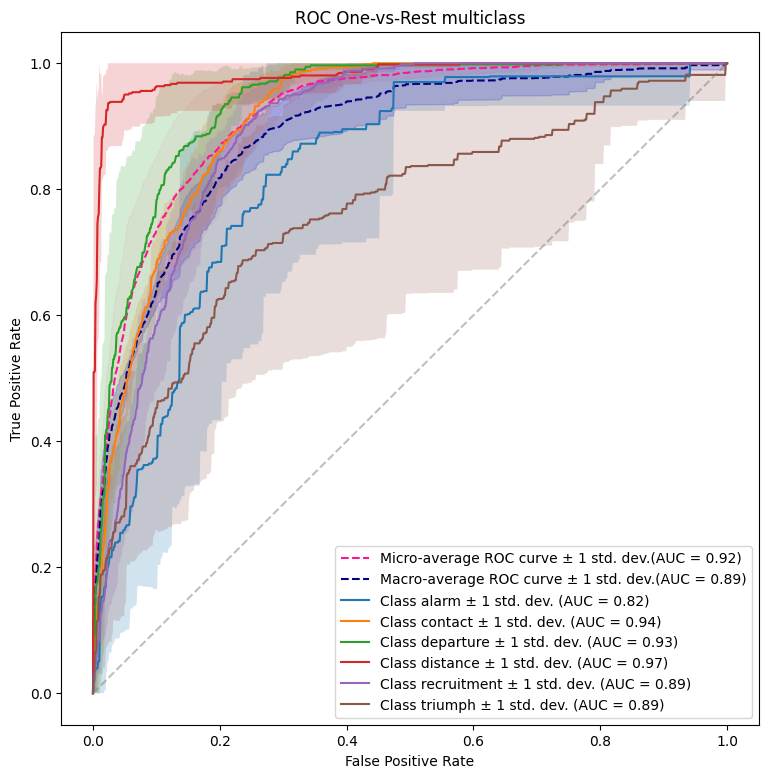

In [88]:
summary = cross_validate(ds_lfcc, LFCCCNN, device, le, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE, n_splits=6, n_epochs=25, n_classes=6)